In [3]:
# import torch
# import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from torchvision.io import read_image
import json, os
import seaborn as sns
import cv2 as cv
# from torch import nn
import plotly.graph_objects as go


# print("PyTorch Version:", torch.__version__)
# print("Torchvision Version:", torchvision.__version__)
# print("GPU Available:", torch.cuda.is_available())
# print("Torchvision CUDA Build:", torchvision.__version__.split('+')[-1] if '+' in torchvision.__version__ else "Default")
# device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f'Usando dispositivo: {device}')

def dice_coef(mask_1, mask_2, title: str, graph=False):
    mask=mask_1+mask_2
    if graph:
        plt.imshow(mask)
        plt.title(title)
        plt.show()
    mask=mask.flatten()
    total_mask=len([i for i in mask if i==1])
    rate_mask=len([i for i in mask if i==2])
    return rate_mask/(total_mask+rate_mask)


def df_dice_image(H, W, annotations_revisor, annotations_persona, pixel_ref=100, interpolation=cv.INTER_AREA):
    label_labeled=[]
    label_ref=[]
    dice_coef_list=[]
    num_obj_labeled=[]
    num_obj_ref=[]
    labeled_mask=[]
    ref_mask=[]
    
    for k_ref ,obj_r in enumerate(annotations_revisor):
        nombre_clase_r = obj_r["labels"]["labelName"]
        puntos_r = np.array(
            [[p["x"], p["y"]] for p in obj_r["content"]],
            dtype=np.int32)
        
        if "frailejon" in nombre_clase_r.lower() and "sinflor" not in nombre_clase_r.lower():
            for k_lab, obj_p in enumerate(annotations_persona):
                nombre_clase_p = obj_p["labels"]["labelName"]
                
                puntos_p = np.array(
                    [[p["x"], p["y"]] for p in obj_p["content"]],
                    dtype=np.int32)
                
                try:
                    del mask_1_rev, mask_1_pers, ref_mask_resized, labeled_mask_resised
                except:
                    pass
                
                if "sinflor" not in nombre_clase_p.lower():
                    # print("no sinflorecencia")
                    label_labeled.append(nombre_clase_p)
                    label_ref.append(nombre_clase_r)
                    num_obj_labeled.append(k_lab)
                    num_obj_ref.append(k_ref)
    
                    
                    mask_1_rev = np.zeros((H, W), dtype=np.uint8)
                    cv.fillPoly(mask_1_rev, [puntos_r], color=1)
                    mask_1_pers = np.zeros((H, W), dtype=np.uint8)
                    cv.fillPoly(mask_1_pers, [puntos_p], color=1)
                    dice_coef_list.append(dice_coef(mask_1_pers, mask_1_rev, title="Pic"))
                    
                    ref_mask_resized=cv.resize(mask_1_rev, (pixel_ref, int(pixel_ref*W/H)), interpolation=interpolation)
                    ref_mask.append(ref_mask_resized)
                    labeled_mask_resised=cv.resize(mask_1_pers, (pixel_ref, int(pixel_ref*W/H)), interpolation=interpolation)
                    labeled_mask.append(labeled_mask_resised)
                    
                    
        
        elif "sinflor" in nombre_clase_r.lower():
            for k_lab, obj_p in enumerate(annotations_persona):
                
                nombre_clase_p = obj_p["labels"]["labelName"]
                puntos_p = np.array(
                    [[p["x"], p["y"]] for p in obj_p["content"]],
                    dtype=np.int32
                )
                try:
                    del mask_2_rev, mask_2_pers, ref_mask_resized, labeled_mask_resised
                except:
                    pass
                
    
                if "sinflor" in nombre_clase_p.lower():
                    # print("Con sinflorecencia")
                    label_labeled.append(nombre_clase_p)
                    label_ref.append(nombre_clase_r)
                    num_obj_labeled.append(k_lab)
                    num_obj_ref.append(k_ref)
                    
                    mask_2_rev = np.zeros((H, W), dtype=np.uint8)
                    cv.fillPoly(mask_2_rev, [puntos_r], color=1)
                    mask_2_pers = np.zeros((H, W), dtype=np.uint8)
                    cv.fillPoly(mask_2_pers, [puntos_p], color=1)
                    dice_coef_list.append(dice_coef(mask_2_pers, mask_2_rev, title="Cruce en etiqueta Sinflorecencia"))
                    
                    ref_mask_resized=cv.resize(mask_2_rev, (pixel_ref, int(pixel_ref*W/H)), interpolation=interpolation)
                    ref_mask.append(ref_mask_resized)
                    labeled_mask_resised=cv.resize(mask_2_pers, (pixel_ref, int(pixel_ref*W/H)), interpolation=interpolation)
                    labeled_mask.append(labeled_mask_resised)
                    
                    
    return label_labeled, label_ref, num_obj_labeled, num_obj_ref, dice_coef_list, labeled_mask, ref_mask

Coeficiente de Dice

$$I_{Dice}=\dfrac{2 |A\cap B|}{|A|+|B|}$$

Leer ruta

In [ ]:
path_person="JuanLeal"
list_person=os.listdir(path_person)
list_images=os.listdir(os.path.join(path_person,list_person[0]))
df_general=pd.DataFrame()

for ima_name in list_images:
    ima=plt.imread(os.path.join(path_person,list_person[0],ima_name))
    # Altura y ancho de la imagen
    Height, Width = ima.shape[:2]
    df_pic=pd.DataFrame()
    #Nombre de la imagen sin extensión y sin prefijo
    pic_name=ima_name.split(".")[0].split("_")[-1]
    
    #Nombre de los json de la persona y del revisor que corresponden a la imagen
    json_referenced_name=[ i for i in os.listdir(os.path.join(path_person,list_person[2])) if pic_name in i ][0]
    json_labeled_name=[ i for i in os.listdir(os.path.join(path_person,list_person[1])) if pic_name in i ][0]
    
    #apertura de los json de la persona y del revisor que corresponden a la imagen
    with open(os.path.join(path_person,list_person[2],json_referenced_name)) as f:
        annotations_revisor = json.load(f)

    with open(os.path.join(path_person,list_person[1],json_labeled_name)) as f:
        annotations_persona = json.load(f)
    
    label_labeled, label_ref, num_obj_labeled, num_obj_ref, dice_coef_list, labeled_mask, ref_mask=df_dice_image(Height, Width, 
                                                                                                                annotations_revisor,
                                                                                                                annotations_persona,
                                                                                                                pixel_ref=128)
    
    df_pic["Name_labeler"]=[path_person]*len(label_labeled)
    df_pic["pic_name"]=[pic_name]*len(label_labeled)
    df_pic["Num_obj_ref"]=num_obj_ref
    df_pic["Num_obj_labeled"]=num_obj_labeled
    df_pic["Label_ref"]=label_ref
    df_pic["Label_labeled"]=label_labeled
    df_pic["Dice_coef"]=dice_coef_list
    df_pic["label_image_reduced"]=labeled_mask
    df_pic["ref_image_reduced"]=ref_mask
    df_pic["Dimesion_image"]=[(Height, Width)] * len(label_labeled)
    
    df_general=pd.concat([df_general, df_pic], ignore_index=True)

df_general["num_parcela"]=df_general["pic_name"].map(lambda x: x.split("C")[0])
df_general.reset_index(drop=True, inplace=True)
df_general.sort_values(by="Dice_coef", ascending=False, inplace=True)
df_general
    

,Name_labeler,pic_name,Num_obj_ref,Num_obj_labeled,Label_ref,Label_labeled,Dice_coef,label_image_reduced,ref_image_reduced,Dimesion_image
188,JuanLeal,P19C3,1,1,Frailejon con sinflorecencias,Sinflorescencia,0.824423,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1548, 1548)"
173,JuanLeal,P19C1,2,3,Frailejon,Frailejon,0.815573,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1962, 2001)"
184,JuanLeal,P19C3,0,2,Frailejon,Frailejon,0.802631,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1548, 1548)"
183,JuanLeal,P19C2,1,2,Frailejon,Frailejon,0.792500,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1934, 2153)"
124,JuanLeal,P15C4,4,0,Frailejon con sinflorecencias,Sinflorescencia,0.742306,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1613, 1757)"
...,...,...,...,...,...,...,...,...,...,...
182,JuanLeal,P19C2,1,1,Frailejon,Frailejon,0.000000,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1934, 2153)"
181,JuanLeal,P19C2,0,2,Frailejon,Frailejon,0.000000,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1934, 2153)"
185,JuanLeal,P19C3,0,3,Frailejon,Frailejon,0.000000,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1548, 1548)"
186,JuanLeal,P19C3,0,4,Frailejon,Frailejon,0.000000,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1548, 1548)"


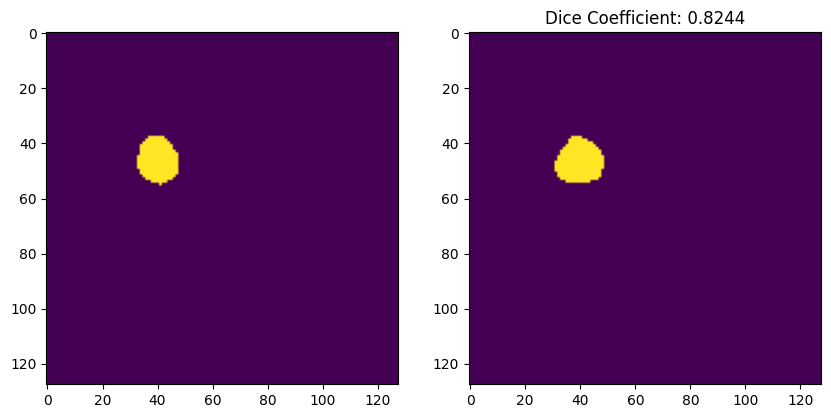

In [19]:
n=0
label_ima=df_general.iloc[n]["label_image_reduced"]
ref_ima=df_general.iloc[n]["ref_image_reduced"]

fig, ax= plt.subplots(1, 2, figsize=(10, 5)) 
ax[0].imshow(label_ima)
ax[1].imshow(ref_ima)
plt.title(f"Dice Coefficient: {df_general.iloc[n]['Dice_coef']:.4f}")
plt.show()